# Logistic Regression - Credit Card Approval Prediction

**DATA 221 — Introduction to Data Science**  
**Author:** Zoya Malik  
**Dataset:** Credit Card Approval Prediction (Kaggle)

---

## What is Logistic Regression?

As we learned in lecture, a linear regression model predicts a continuous value using:

$$\hat{y} = \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n + \alpha$$

The $\beta$ values are regression coefficients and $\alpha$ is the intercept learned from data.

But for classification (predicting 0 or 1), a linear model gives values outside [0, 1], which are hard to interpret as a class. Logistic regression fixes this by passing the linear output through a logistic (sigmoid) function:

$$P(\text{class}=1) = \frac{1}{1 + e^{-(\beta_1 x_1 + \cdots + \beta_n x_n + \alpha)}}$$

This converts any value into a probability between 0 and 1:
- Probability > 0.5 → predict **class 1** (high risk)  
- Probability ≤ 0.5 → predict **class 0** (low risk)

Logistic regression is used as our baseline model it's simple, fast, and interpretable.

---

> ⚠️ **Run `data_preprocessing.ipynb` first** to generate `cleaned_data.csv` before running this notebook.

## Step 1: Import Libraries

In [9]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Machine learning — from sklearn, just like in lecture
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Cleaned Data

We load `cleaned_data.csv` which was produced by `data_preprocessing.ipynb`.  
All feature engineering and cleaning is already done this notebook focuses entirely on the model.

In [10]:
# Load the shared cleaned dataset
df = pd.read_csv('../data/cleaned_data.csv')

print('Dataset shape:', df.shape)
print()
print('Columns:', df.columns.tolist())
print()
df.head()

Dataset shape: (36457, 18)

Columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET', 'AGE', 'YEARS_EMPLOYED']



,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,1,32.890411,12.443836
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,1,32.890411,12.443836
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58.832877,3.106849
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52.356164,8.358904
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52.356164,8.358904


In [12]:
# Confirm class distribution
n_bad  = df['TARGET'].sum()
n_good = len(df) - n_bad
print('Class distribution:')
print(f'  Low risk  (0): {n_good:,}  ({n_good/len(df)*100:.1f}%)')
print(f'  High risk (1): {n_bad:,}   ({n_bad/len(df)*100:.1f}%)')
print()
print('Note: Imbalanced dataset - F1-Score and ROC-AUC are more informative than Accuracy alone.')

Class distribution:
  Low risk  (0): 32,166  (88.2%)
  High risk (1): 4,291   (11.8%)

Note: Imbalanced dataset - F1-Score and ROC-AUC are more informative than Accuracy alone.


## Step 3: Separate Features and Target

In [13]:
# Separate features (X) and target variable (y)
X = df.drop(columns=['TARGET'])
y = df['TARGET']

print('Features (X):', X.shape)
print('Target   (y):', y.shape)

Features (X): (36457, 17)
Target   (y): (36457,)


## Step 4: Train-Test Split

As taught in lecture, we split into **80% training** and **20% testing**.  
`random_state=42` ensures every team member gets the **identical split** — required for a fair model comparison.

In [14]:
# 80/20 split — same random_state=42 across all team notebooks
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps class proportions equal in both sets
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Testing set:  {X_test.shape[0]:,} samples')
print()
print('Training class distribution:')
print(y_train.value_counts())

Training set: 29,165 samples
Testing set:  7,292 samples

Training class distribution:
TARGET
0    25732
1     3433
Name: count, dtype: int64


## Step 5: Preprocessing

Even though the data was cleaned in `data_preprocessing.ipynb`, we still need to:
1. **Handle any remaining missing values** — median for numerical, mode for categorical  
2. **Encode categorical variables** — convert text to numbers  
3. **Standardize numerical features** — scale so no single feature dominates

⚠️ All of these steps are **fit on training data only**, then applied to the test set to prevent data leakage.

In [15]:
# ---- Identify column types ----
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X_train.select_dtypes(include=['number']).columns.tolist()

print('Categorical columns:', categorical_cols)
print()
print('Numerical columns:  ', numerical_cols)

Categorical columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

Numerical columns:   ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED']


In [16]:
# ---- Handle missing values ----
# Numerical  → fill with MEDIAN (fit on training only)
# Categorical → fill with MODE  (fit on training only)

num_medians = X_train[numerical_cols].median()
X_train[numerical_cols] = X_train[numerical_cols].fillna(num_medians)
X_test[numerical_cols]  = X_test[numerical_cols].fillna(num_medians)

for col in categorical_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col]  = X_test[col].fillna(mode_val)

print('Missing values remaining:')
print('  Training:', X_train.isnull().sum().sum())
print('  Testing: ', X_test.isnull().sum().sum())

Missing values remaining:
  Training: 0
  Testing:  0


In [17]:
# ---- Encode categorical variables ----
# One-hot encoding: converts each category into a 0/1 column
# drop_first=True avoids the dummy variable trap

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

# Align columns — test set must match train set exactly
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print('After encoding:')
print('  Training shape:', X_train.shape)
print('  Testing shape: ', X_test.shape)

After encoding:
  Training shape: (29165, 46)
  Testing shape:  (7292, 46)


In [18]:
# ---- Standardize numerical features ----
# Formula: x' = (x - mean) / std
# Fit on training data only, then apply to both

scaler = StandardScaler()
num_cols_to_scale = [c for c in numerical_cols if c in X_train.columns]

X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])

print(f'Standardization complete. Total features: {X_train.shape[1]}')

Standardization complete. Total features: 46


## Step 6: Train the Logistic Regression Model

We use `LogisticRegression` from sklearn the same way `LinearRegression` was used in lecture.

`class_weight='balanced'` tells the model to pay extra attention to high-risk applicants since they are the minority class.

In [20]:
# Define and train the model
log_reg_model = LogisticRegression(
    class_weight='balanced',  # handles class imbalance
    max_iter=1000,            # enough iterations to converge
    random_state=42
)

log_reg_model.fit(X_train, y_train)

print('Model trained successfully!')
print(f'Features used: {X_train.shape[1]}')

Model trained successfully!
Features used: 46


## Step 7: Make Predictions

We predict on the test set — data the model has never seen — for an honest evaluation.

In [22]:
# Predict class labels (0 or 1)
y_pred = log_reg_model.predict(X_test)

# Predict probabilities (needed for ROC-AUC)
# predict_proba gives [P(class=0), P(class=1)] we take column 1
y_prob = log_reg_model.predict_proba(X_test)[:, 1]

print('Predictions made!')
print(f'Sample labels:        {y_pred[:10]}')
print(f'Sample probabilities: {y_prob[:10].round(3)}')

Predictions made!
Sample labels:        [0 0 0 0 0 1 0 1 1 1]
Sample probabilities: [0.436 0.47  0.488 0.46  0.262 0.518 0.415 0.504 0.577 0.56 ]


## Step 8: Evaluate the Model

As taught in lecture, we measure classification performance using:

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP+TN) / (TP+TN+FP+FN) | Overall correct predictions |
| **Precision** | TP / (TP+FP) | Of predicted high-risk, how many really are? |
| **Recall** | TP / (TP+FN) | Of actual high-risk, how many did we catch? |
| **F1-Score** | 2×P×R / (P+R) | Balance of precision and recall |
| **ROC-AUC** | Area under ROC curve | Overall separation between classes |

Recall is especially important here — missing a real defaulter is costly.

In [23]:
# Calculate all metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print('=' * 45)
print('  LOGISTIC REGRESSION — EVALUATION RESULTS')
print('=' * 45)
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')
print(f'  ROC-AUC:   {roc_auc:.4f}')
print('=' * 45)

  LOGISTIC REGRESSION — EVALUATION RESULTS
  Accuracy:  0.5706
  Precision: 0.1354
  Recall:    0.4918
  F1-Score:  0.2123
  ROC-AUC:   0.5491


In [24]:
# Full classification report
print(classification_report(y_test, y_pred, target_names=['Low Risk (0)', 'High Risk (1)']))

               precision    recall  f1-score   support

 Low Risk (0)       0.90      0.58      0.70      6434
High Risk (1)       0.14      0.49      0.21       858

     accuracy                           0.57      7292
    macro avg       0.52      0.54      0.46      7292
 weighted avg       0.81      0.57      0.65      7292



### Confusion Matrix

The confusion matrix (from lecture) shows our four prediction outcomes:
- **TP** - correctly caught high-risk applicants  
- **TN** - correctly cleared low-risk applicants  
- **FP** - false alarms (predicted high-risk but actually fine)  
- **FN** - missed defaulters ← most costly outcome

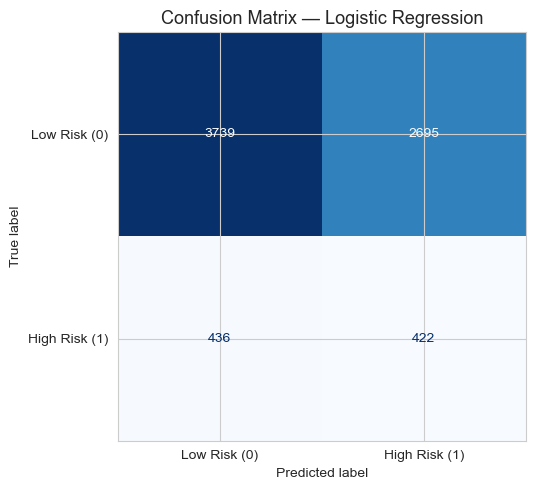

True Negatives  (TN):  3739  - correctly predicted low risk
False Positives (FP):  2695  - predicted high risk, actually low risk
False Negatives (FN):   436  - predicted low risk, actually high risk
True Positives  (TP):   422  - correctly predicted high risk


In [27]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low Risk (0)', 'High Risk (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn:5d}  - correctly predicted low risk')
print(f'False Positives (FP): {fp:5d}  - predicted high risk, actually low risk')
print(f'False Negatives (FN): {fn:5d}  - predicted low risk, actually high risk')
print(f'True Positives  (TP): {tp:5d}  - correctly predicted high risk')

### ROC Curve

The ROC curve shows how well the model separates the two classes across all probability thresholds. AUC = 1.0 is perfect; AUC = 0.5 is no better than random guessing.

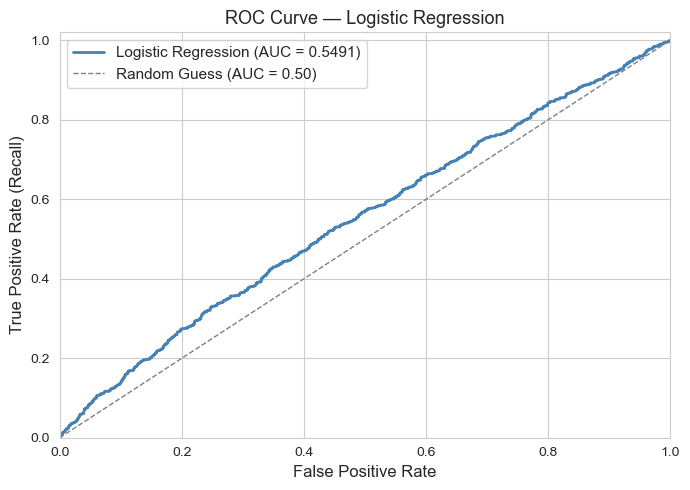

In [28]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Logistic Regression (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1,
        label='Random Guess (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Logistic Regression', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## Step 9: Model Interpretation

A key advantage of logistic regression is that we can directly read the coefficients to understand what the model learned — as taught in lecture.

Each coefficient $\beta_i$ shows the effect of that feature:
- **Positive** → increases probability of high risk  
- **Negative** → decreases probability of high risk  
- **Larger absolute value** → more influence

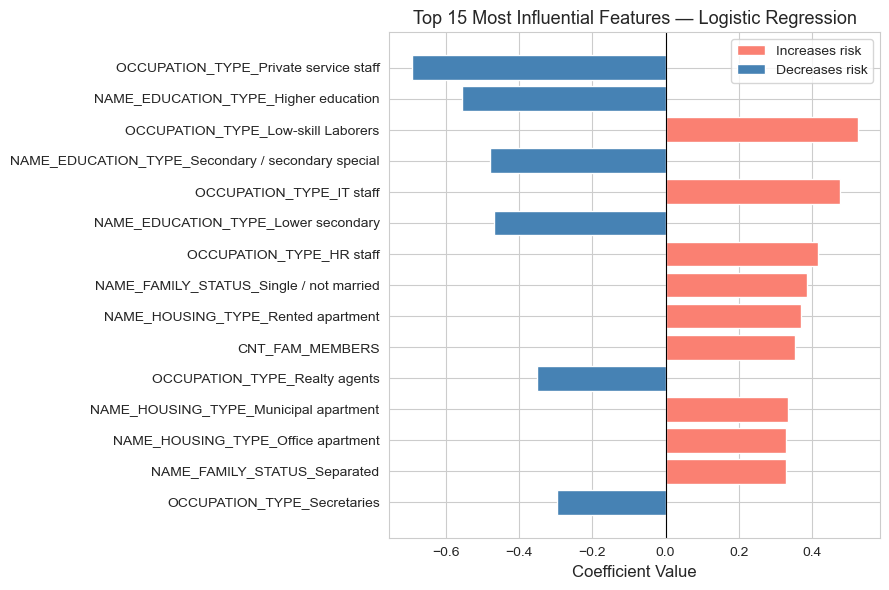

Top 10 most influential features:
                                          Feature  Coefficient
            OCCUPATION_TYPE_Private service staff    -0.694621
             NAME_EDUCATION_TYPE_Higher education    -0.556925
               OCCUPATION_TYPE_Low-skill Laborers     0.525874
NAME_EDUCATION_TYPE_Secondary / secondary special    -0.479662
                         OCCUPATION_TYPE_IT staff     0.478768
              NAME_EDUCATION_TYPE_Lower secondary    -0.468864
                         OCCUPATION_TYPE_HR staff     0.418475
          NAME_FAMILY_STATUS_Single / not married     0.387557
               NAME_HOUSING_TYPE_Rented apartment     0.370106
                                  CNT_FAM_MEMBERS     0.354085


In [29]:
# Extract and sort coefficients by importance
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': log_reg_model.coef_[0]
})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False)

top15 = coef_df.head(15)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['salmon' if c > 0 else 'steelblue' for c in top15['Coefficient']]
ax.barh(top15['Feature'], top15['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Top 15 Most Influential Features — Logistic Regression', fontsize=13)
ax.invert_yaxis()
ax.legend(handles=[
    Patch(facecolor='salmon',    label='Increases risk'),
    Patch(facecolor='steelblue', label='Decreases risk')
], fontsize=10)
plt.tight_layout()
plt.show()

print('Top 10 most influential features:')
print(coef_df[['Feature', 'Coefficient']].head(10).to_string(index=False))

## Step 10: Summary

In [30]:
print('=' * 52)
print('  LOGISTIC REGRESSION — FINAL SUMMARY')
print('=' * 52)
print(f'  Dataset:          cleaned_data.csv ({len(df):,} applicants)')
print(f'  Features:         {X_train.shape[1]}')
print(f'  Train/Test split: 80% / 20%  (random_state=42)')
print()
print('  Performance on Test Set:')
print(f'    Accuracy:  {accuracy:.4f}')
print(f'    Precision: {precision:.4f}')
print(f'    Recall:    {recall:.4f}')
print(f'    F1-Score:  {f1:.4f}')
print(f'    ROC-AUC:   {roc_auc:.4f}')
print('=' * 52)
print()
print('  This is the BASELINE model for our project.')
print('  Teammates (KNN, Decision Tree, Neural Network) will')
print('  be compared against these results.')
print('=' * 52)

  LOGISTIC REGRESSION — FINAL SUMMARY
  Dataset:          cleaned_data.csv (36,457 applicants)
  Features:         46
  Train/Test split: 80% / 20%  (random_state=42)

  Performance on Test Set:
    Accuracy:  0.5706
    Precision: 0.1354
    Recall:    0.4918
    F1-Score:  0.2123
    ROC-AUC:   0.5491

  This is the BASELINE model for our project.
  Teammates (KNN, Decision Tree, Neural Network) will
  be compared against these results.


---

## References

- Haratian, A., & Ramazi, P. (2024). *Lecture 10: Simple and Multiple Regression & Logistic Regression*. University of Calgary.
- Haratian, A., & Ramazi, P. (2024). *Lecture 9: Machine Learning, Model Fitting & Validation*. University of Calgary.
- Kaggle. (2024). *Credit Card Approval Prediction Dataset*. https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction